In [ ]:
# Anaconda Environment 3.10.11
# conda install -c conda-forge opencv
# conda install numpy 
# conda install matplotlib

In [3]:
# Test the conversion of a semantic segmentation label to an overlay image
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ==== INPUT: Provide full paths ====
image_path = 'dataset/images/DJI_0175_1_0051.JPG'
label_path = 'dataset/labels/DJI_0175_1_0051.png'

# ==== LOAD IMAGE AND LABEL ====
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

label = cv2.imread(label_path, cv2.IMREAD_GRAYSCALE)

# ==== DEFINE COLOR MAP ====
# You can change the colors to match your dataset
colors = {
    0: [0, 0, 0],         # background (invisible)
    1: [128, 64, 128],    # soil - purple
    2: [0, 255, 0],       # crop - green
    3: [70, 130, 180],    # sky - blue
}

# ==== CREATE COLOR MASK ====
colored_mask = np.zeros_like(image)

for class_index, color in colors.items():
    mask = label == class_index
    colored_mask[mask] = color

# ==== OVERLAY ====
alpha = 0.5  # Transparency factor
overlayed = cv2.addWeighted(image, 1 - alpha, colored_mask, alpha, 0)

# ==== DISPLAY ====
plt.figure(figsize=(8, 6))
plt.imshow(overlayed)
plt.axis("off")
plt.title("Semantic Segmentation Overlay")
plt.show()

['c:\\Users\\haito\\.conda\\envs\\tomatoData\\python310.zip', 'C:/Users/haito/.conda/envs/tomatoDaata/Lib/site-packages/cv2\\python-3.10', 'c:\\Users\\haito\\.conda\\envs\\tomatoData\\DLLs', 'c:\\Users\\haito\\.conda\\envs\\tomatoData\\lib', 'c:\\Users\\haito\\.conda\\envs\\tomatoData', '', 'c:\\Users\\haito\\.conda\\envs\\tomatoData\\lib\\site-packages', 'c:\\Users\\haito\\.conda\\envs\\tomatoData\\lib\\site-packages\\win32', 'c:\\Users\\haito\\.conda\\envs\\tomatoData\\lib\\site-packages\\win32\\lib', 'c:\\Users\\haito\\.conda\\envs\\tomatoData\\lib\\site-packages\\Pythonwin']


ImportError: ERROR: recursion is detected during loading of "cv2" binary extensions. Check OpenCV installation.

In [4]:
# Converison of the dataset to YOLO format
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ==== INPUT: Provide full paths ====
image_path = 'dataset/images/DJI_0175_1_0051.JPG'
label_path = 'dataset/labels/DJI_0175_1_0051.png'

# ==== LOAD IMAGE AND LABEL ====
image = cv2.imread(image_path)
label = cv2.imread(label_path, cv2.IMREAD_GRAYSCALE)

height, width = label.shape

# ==== PROCESS EACH CLASS ====
class_ids = np.unique(label)
class_ids = class_ids[class_ids != 0]  # skip background (0)

yolo_lines = []

for class_id in class_ids:
    binary_mask = (label == class_id).astype(np.uint8) * 255

    # Find contours for this class
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    for contour in contours:
        if contour.shape[0] < 3:
            continue  # YOLO requires at least a triangle

        points = contour.squeeze()
        if len(points.shape) != 2:
            continue  # skip bad contours

        normalized_points = []
        for x, y in points:
            x_norm = x / width
            y_norm = y / height
            normalized_points.extend([x_norm, y_norm])

        line = f"{class_id} " + " ".join([f"{p:.6f}" for p in normalized_points])
        yolo_lines.append(line)

# ==== WRITE OUTPUT ====
image_filename = os.path.splitext(os.path.basename(image_path))[0]
output_txt = f"{image_filename}.txt"

with open(output_txt, "w") as f:
    f.write("\n".join(yolo_lines))

print(f"YOLO segmentation saved to: {output_txt}")


YOLO segmentation saved to: DJI_0175_1_0051.txt


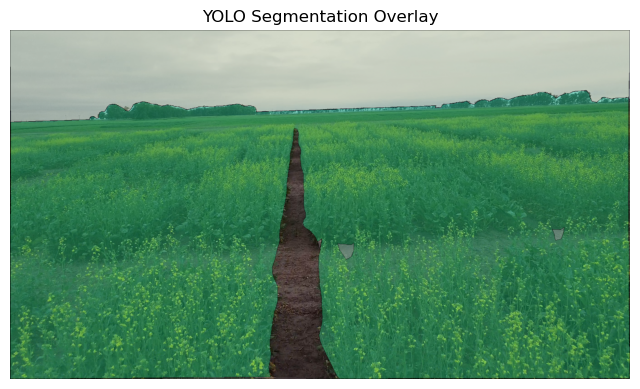

In [7]:
#Testing the YOLO Converted Dataset

import cv2
import numpy as np
import random
import os
# ==== INPUT ====
image_path = 'dataset/images/DJI_0175_1_0051.JPG'
txt_path = "DJI_0175_1_0051.txt"  # must match image filename

# ==== LOAD IMAGE ====
image = cv2.imread(image_path)
if image is None:
    raise ValueError(f"Could not load image: {image_path}")

height, width = image.shape[:2]

# ==== CLASS COLORS ====
# Predefine or randomly assign colors per class
class_colors = {}

def get_color_for_class(class_id):
    if class_id not in class_colors:
        class_colors[class_id] = [random.randint(0, 255) for _ in range(3)]
    return class_colors[class_id]

# ==== READ AND PARSE TXT FILE ====
with open(txt_path, "r") as f:
    lines = f.readlines()

for line in lines:
    parts = line.strip().split()
    if len(parts) < 7:  # class + at least 3 points (x, y)
        continue

    class_id = int(parts[0])
    coords = list(map(float, parts[1:]))
    points = np.array([[int(x * width), int(y * height)] for x, y in zip(coords[0::2], coords[1::2])], dtype=np.int32)

    # Draw polygon with transparency
    overlay = image.copy()
    cv2.fillPoly(overlay, [points], color=get_color_for_class(class_id))
    image = cv2.addWeighted(overlay, 0.4, image, 0.6, 0)

    # Optionally, draw polygon outline
    cv2.polylines(image, [points], isClosed=True, color=(0, 0, 0), thickness=1)

# ==== DISPLAY RESULT ====
plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("YOLO Segmentation Overlay")
plt.show()

In [ ]:
# Full Conversion of the dataset to YOLO format
import cv2
import numpy as np
import os

# ==== INPUT: CHANGE THESE PATHS ====
images_folder = "dataset/images"
labels_folder = "dataset/labels"
output_txt_folder = "dataset/txt"

# Create output directory if it doesn't exist
os.makedirs(output_txt_folder, exist_ok=True)

# ==== PROCESS EACH IMAGE ====
for filename in os.listdir(images_folder):
    if not filename.lower().endswith(('.jpg', '.jpeg', '.png')):
        continue

    image_path = os.path.join(images_folder, filename)
    label_filename = os.path.splitext(filename)[0] + ".png"
    label_path = os.path.join(labels_folder, label_filename)

    if not os.path.exists(label_path):
        print(f"Label not found for {filename}, skipping.")
        continue

    image = cv2.imread(image_path)
    label = cv2.imread(label_path, cv2.IMREAD_GRAYSCALE)

    height, width = label.shape
    class_ids = np.unique(label)
    class_ids = class_ids[class_ids != 0]  # skip background

    yolo_lines = []

    for class_id in class_ids:
        binary_mask = (label == class_id).astype(np.uint8) * 255
        contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        for contour in contours:
            if contour.shape[0] < 3:
                continue

            points = contour.squeeze()
            if len(points.shape) != 2:
                continue 

            normalized_points = []
            for x, y in points:
                x_norm = x / width
                y_norm = y / height
                normalized_points.extend([x_norm, y_norm])

            line = f"{class_id} " + " ".join([f"{p:.6f}" for p in normalized_points])
            yolo_lines.append(line)

    # ==== WRITE TO TXT FILE ====
    output_txt_path = os.path.join(output_txt_folder, os.path.splitext(filename)[0] + ".txt")
    with open(output_txt_path, "w") as f:
        f.write("\n".join(yolo_lines))

    print(f"Saved: {output_txt_path}")

Saved: dataset/txt\DJI_0048_01.txt
Saved: dataset/txt\DJI_0048_02.txt
Saved: dataset/txt\DJI_0048_03.txt
Saved: dataset/txt\DJI_0048_04.txt
Saved: dataset/txt\DJI_0048_05.txt
Saved: dataset/txt\DJI_0048_06.txt
Saved: dataset/txt\DJI_0163_0001.txt
Saved: dataset/txt\DJI_0163_0004.txt
Saved: dataset/txt\DJI_0163_0008.txt
Saved: dataset/txt\DJI_0175_1_0003.txt
Saved: dataset/txt\DJI_0175_1_0004.txt
Saved: dataset/txt\DJI_0175_1_0008.txt
Saved: dataset/txt\DJI_0175_1_0011.txt
Saved: dataset/txt\DJI_0175_1_0013.txt
Saved: dataset/txt\DJI_0175_1_0014.txt
Saved: dataset/txt\DJI_0175_1_0016.txt
Saved: dataset/txt\DJI_0175_1_0039.txt
Saved: dataset/txt\DJI_0175_1_0051.txt
Saved: dataset/txt\DJI_0317_0001.txt
Saved: dataset/txt\DJI_0317_0005.txt
Saved: dataset/txt\DJI_0317_0027.txt
Saved: dataset/txt\DJI_0317_0028.txt
Saved: dataset/txt\DJI_0317_0029.txt
Saved: dataset/txt\DJI_0317_0038.txt
Saved: dataset/txt\DJI_0317_0042.txt
Saved: dataset/txt\DJI_0317_0044.txt
Saved: dataset/txt\DJI_0317_0045

In [2]:
import os
import shutil
import random

# Set your dataset directory paths
images_dir = "dataset/images"  # directory containing images
labels_dir = "dataset/labels"     # directory containing label txt files

# Output directories
output_train_images = "../train/images"
output_train_labels = "../train/labels"
output_val_images = "../val/images"
output_val_labels = "../val/labels"

# Create output directories if they don't exist
os.makedirs(output_train_images, exist_ok=True)
os.makedirs(output_train_labels, exist_ok=True)
os.makedirs(output_val_images, exist_ok=True)
os.makedirs(output_val_labels, exist_ok=True)

# Get list of image files (assuming .jpg, change if needed)
image_files = [f for f in os.listdir(images_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
random.shuffle(image_files)

# Split into train and val
train_count = int(0.8 * len(image_files))
train_images = image_files[:train_count]
val_images = image_files[train_count:]

def copy_files(image_list, img_src, lbl_src, img_dst, lbl_dst):
    for img_file in image_list:
        base_name = os.path.splitext(img_file)[0]
        label_file = base_name + ".txt"
        # Copy image
        shutil.copy(os.path.join(img_src, img_file), os.path.join(img_dst, img_file))
        # Copy label if exists
        label_path = os.path.join(lbl_src, label_file)
        if os.path.exists(label_path):
            shutil.copy(label_path, os.path.join(lbl_dst, label_file))

# Copy training files
copy_files(train_images, images_dir, labels_dir, output_train_images, output_train_labels)
# Copy validation files
copy_files(val_images, images_dir, labels_dir, output_val_images, output_val_labels)

In [2]:
import os

# ==== PATH TO YOUR LABELS FOLDER ====
labels_folder = "datasetFinal/val/labels"

# ==== COLLECT ALL CLASS IDS ====
all_class_ids = set()

for filename in os.listdir(labels_folder):
    if filename.endswith(".txt"):
        file_path = os.path.join(labels_folder, filename)

        with open(file_path, "r") as f:
            for line in f:
                if line.strip() == "":
                    continue
                parts = line.strip().split()
                if len(parts) < 1:
                    continue
                class_id = int(parts[0])
                all_class_ids.add(class_id)

# ==== OUTPUT ====
sorted_classes = sorted(all_class_ids)
print(f"Number of unique classes: {len(sorted_classes)}")
print(f"Class IDs: {sorted_classes}")

Number of unique classes: 5
Class IDs: [2, 3, 4, 5, 6]
